In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pimcs import jspin, destroy, Dicke, ground, mcsolve

# setup system in exactly same way as with qutip.piqs
N = 500
OmegaC = 1.0
OmegaA = 0.5
Coupling = 0.9 / np.sqrt(N)

a = destroy(4) # increase cavity truncation if needed (varies depending on problem)
               # if unsure, set higher at small N, then keep decreasing if results do not change,
               # then keep it at this value for large N - should not need to grow with N.
Jx, Jy, Jz = jspin(N)

# one can also use spin-lowering and -raising operators
# Jp = jspin(N, '+')
# Jm = jspin(N, '-')

# Example: Dicke Model
H = OmegaC * a.dag()*a + OmegaA * 2*Jz + Coupling * 2*Jx * (a.dag() + a)

# construct system in the same way, now with cavity loss for (a),
# cavity_emission for (a†σ-) and cavity_absorption for (aσ+)
system = Dicke(N, H, cavity_loss = 1.0, emission = 0.2, dephasing = 0.0)

# construct initial state, can use dicke(j,m), ground(N), exicted(N)
# or rotated_qubits(N, θ) for (tensorproduct)_i  exp(-i θ/2 σx) |up>_i

psi0 = ground(N)
times = np.linspace(0, 40, 300)

# similar interface to qutip.mcsolve
# IMPORTANT: a low number of trajectories (~25) is usually sufficient for large N

data = mcsolve(
    system,
    psi0,               # initial state of simulations
    times,              # times to output expecation values (must be linearly spaced for now)
    [a.dag()*a, Jz],    # operators of expectation values to output
    ntraj = 200,        # number of Monte Carlo simulations to run 
    ncpu = 8,           # number of simulations to run in parallel (ideally = number of CPU cores)
    jtol = 0.05         # parameter to tune integration step size (lower is more accurate but slower)
)

Building optimized executable...
Running trajectories...


Trajectory [200/200] completed, average time: 0.956 seconds.


Steady state photon count per emitter: 0.304


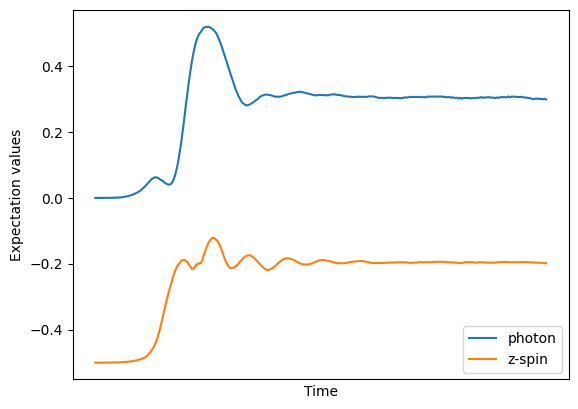

In [2]:
# obtain expectation values the same way as from qutip
# these are all complex for now: smarter Hermitian detection will come later

photon = data.expect[0].real
spin = data.expect[1].real

plt.plot(times, photon / N, label = "photon")
plt.plot(times, spin / N, label = "z-spin")
plt.xticks([])
plt.xlabel("Time")
plt.ylabel("Expectation values")
plt.legend(loc = "lower right")

steady_state_photon = np.mean(photon[times > 30]) / N
print(f"Steady state photon count per emitter: {steady_state_photon:.3f}")